# Clasificación de cinco gestos con una IMU
**Inteligencia Artificial de Borde**

**Integrantes:** William David Olaya y Nelson Leonardo Hernandez.

Se utilizó una placa **Arduino Nano BLE Sense colocada en la mano** para registrar
movimientos de arriba, abajo, izquierda, derecha y círculo. El dataset recibido
contiene 40 grabaciones por gesto. Los identificadores de captura corresponden
a participante_01 y sesion_01; se conservan sin atribuirlos a un integrante.
El procedimiento y el alcance de la información registrada están en
`PROTOCOLO_CAPTURA.md`.

| Requisito del laboratorio | Dónde se desarrolla |
|---|---|
| Descargar el repositorio, señales por clase y características | B y C |
| Dispersión en el espacio 2D/3D que mejor separe las clases | F |
| Dividir en entrenamiento y prueba | D |
| Clasificador propio con funciones que delimitan regiones | G y H |

**Cómo usarlo:** la URL del grupo ya está configurada. Ejecutar las celdas en orden en
Google Colab. La partición se hace antes de elegir características o ajustar
PCA/LDA. La selección se realiza con validación agrupada dentro de entrenamiento.

**Estado de esta entrega:** incluye una ejecución local con los datos adjuntos.
Repositorio del grupo: [clasificacion-gestos-IMU](https://github.com/williamolaya03-dotcom/clasificacion-gestos-IMU).
La descarga completa queda pendiente de subir los archivos y ejecutar el cuaderno
en una sesión nueva de Colab. La ejecución incluida utiliza la copia local.


## A. Configuración
La URL del grupo está configurada. Con `RAMA` vacío se utiliza la rama predeterminada de GitHub. Los parámetros de ventana se conservan de la versión recibida.


In [1]:
REPO_URL = "https://github.com/williamolaya03-dotcom/clasificacion-gestos-IMU"
RAMA = ""  # Vacío: utilizar la rama predeterminada del repositorio.
RANDOM_STATE = 42
TEST_SIZE = 0.30
N_PLIEGUES = 5
VENTANA_S = 1.5
SOLAPE = 0.5
REGULARIZACION = 0.05


## B. Descargar el repositorio
La raíz del repositorio debe contener `scripts/`, `data/` y `notebooks/`. El repositorio debe ser accesible desde Colab. Al ejecutar desde una copia local completa, se reutilizan esos archivos y se informa que la descarga remota no fue comprobada.


In [2]:
from pathlib import Path
from urllib.parse import urlparse
import os, sys, subprocess, importlib.util, json

def es_proyecto(p):
    return (p / "scripts/extraer_caracteristicas.py").is_file() and (p / "data/raw").is_dir()

candidatas = [Path.cwd(), Path.cwd().parent, Path.cwd() / "proyecto_gestos_imu"]
raiz = next((p.resolve() for p in candidatas if es_proyecto(p)), None)
if raiz is None:
    if not REPO_URL.strip():
        raise ValueError("Completa REPO_URL en la sección A con la URL real del repositorio y vuelve a ejecutar.")
    url = REPO_URL.strip().rstrip("/")
    if url.endswith(".git"):
        url = url[:-4]
    partes = urlparse(url)
    if partes.scheme != "https" or partes.netloc != "github.com" or len(partes.path.strip("/").split("/")) != 2:
        raise ValueError("Usa la dirección HTTPS de la página principal del repositorio de GitHub.")
    destino = Path.cwd() / "proyecto_gestos_imu"
    if destino.exists():
        raise RuntimeError("Ya existe una carpeta incompleta llamada proyecto_gestos_imu. Reinicia la sesión de Colab y vuelve a ejecutar.")
    comando_git = ["git", "clone", "--depth", "1"]
    if RAMA.strip():
        comando_git.extend(["--branch", RAMA.strip()])
    comando_git.extend([url + ".git", str(destino)])
    subprocess.run(comando_git, check=True)
    raiz = destino.resolve()
    if not es_proyecto(raiz):
        raise RuntimeError("La raíz descargada debe contener scripts/ y data/raw/. Revisa la estructura de GitHub.")
    print("Repositorio descargado desde GitHub:", url)
else:
    print("Se utiliza una copia local completa. La descarga desde GitHub no se comprueba en esta ejecución.")

os.chdir(raiz)
sys.path.insert(0, str(raiz / "scripts"))
for carpeta in ("figures", "metrics", "models"):
    (raiz / "results" / carpeta).mkdir(parents=True, exist_ok=True)

dependencias = {"numpy": "numpy", "pandas": "pandas", "scipy": "scipy",
                "sklearn": "scikit-learn", "matplotlib": "matplotlib", "joblib": "joblib"}
faltantes = [pkg for mod, pkg in dependencias.items() if importlib.util.find_spec(mod) is None]
if faltantes:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *faltantes], check=True)
print("Carpetas disponibles:", [p.name for p in raiz.iterdir() if p.is_dir() and p.name in ("data", "scripts", "notebooks", "arduino")])


Se utiliza una copia local completa. La descarga desde GitHub no se comprueba en esta ejecución.
Carpetas disponibles: ['scripts', 'notebooks', 'data', 'arduino']


## C. Generar y cargar las características
Cada CSV original registra `timestamp_ms, ax, ay, az, gx, gy, gz`.
Se añaden $\|a\|=\sqrt{a_x^2+a_y^2+a_z^2}$ y
$\|\omega\|=\sqrt{g_x^2+g_y^2+g_z^2}$.
Así se obtienen **6 características × 8 canales = 48 características**.

| Característica | Qué resume |
|---|---|
| Media | Valor promedio de la ventana. |
| Varianza | Dispersión respecto al promedio; se utiliza el estimador muestral. |
| Curtosis | Momento de cuarto orden; se usa exceso de curtosis de Fisher corregido por sesgo. |
| Asimetría | Desbalance de la distribución, `skewness`, corregido por sesgo. |
| Entropía | Distribución de amplitudes en 16 intervalos; probabilidades del histograma. |
| Energía media | $E=\frac{1}{N}\sum x_i^2$; energía discreta normalizada por el número de muestras. |

Las fórmulas están implementadas en `scripts/extraer_caracteristicas.py`.
Se regenera el archivo básico para mantenerlo coherente con los parámetros de A.
Las señales originales se conservan: la limpieza se realiza durante el procesamiento.
El archivo extendido y su reporte se mantienen como material adicional.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import sklearn, scipy, joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from extraer_caracteristicas import Config, main as extraer, cargar_y_limpiar
from clasificador_geometrico import (ClasificadorGaussianoCuadratico, criterio_fisher,
                                     mejores_combinaciones, graficar_dispersion_2d,
                                     graficar_dispersion_3d, _COLORES)

cfg = Config(modo="ventana", conjunto="basico", ventana_s=VENTANA_S, solape=SOLAPE,
             salida="data/processed/caracteristicas_gestos.csv",
             reporte="data/processed/reporte_extraccion.json")
assert extraer(cfg) == 0
df = pd.read_csv(cfg.salida, dtype={"participant_id": str, "session_id": str})
META = ["gesture", "participant_id", "session_id", "repetition_id", "recording_id",
        "window_id", "segment_id", "source_file", "n_muestras", "fs_hz", "duracion_s"]
X = df.drop(columns=META)
y = df["gesture"].to_numpy()
grupos = df["recording_id"].to_numpy()
assert X.shape[1] == 48 and np.isfinite(X.to_numpy()).all()
assert df["segment_id"].is_unique and df["gesture"].nunique() == 5
print("\nResumen por clase:")
print(df.groupby("gesture").agg(grabaciones=("recording_id", "nunique"), ventanas=("window_id", "size")).to_string())
print("\nDimensiones:", X.shape, "(ventanas, características)")
print("Frecuencia estimada mediana:", df.fs_hz.median(), "Hz")


=== EXTRACCION DE CARACTERISTICAS ===
modo=ventana  conjunto=basico  bins_entropia=16

=== RESUMEN ===
Archivos encontrados : 200
Archivos procesados  : 200
Archivos descartados : 0
Segmentos extraidos  : 600
Caracteristicas      : 48
NaN en la salida     : 0
fs estimada (Hz)     : mediana=31.25  [30.303, 31.25]
Segmentos por clase  :
   - abajo      120
   - arriba     120
   - circulo    120
   - derecha    120
   - izquierda  120

Grabaciones con discontinuidades corregidas:
   - data/raw/derecha/participante_01_sesion_01_rep_001.csv: -2 muestras (hueco maximo 130623 ms)
   - data/raw/izquierda/participante_01_sesion_01_rep_001.csv: -1 muestras (hueco maximo 2695 ms)

Grabaciones con muestras en saturacion del sensor:
   - data/raw/circulo/participante_01_sesion_01_rep_025.csv: 1 muestra(s)

CSV      -> data/processed/caracteristicas_gestos.csv
Reporte  -> data/processed/reporte_extraccion.json

Resumen por clase:
           grabaciones  ventanas
gesture                         
aba

## D. Dividir en entrenamiento y prueba
Se reserva el 30 % de las **grabaciones**, manteniendo juntas todas sus ventanas.
Una ventana y otra de la misma grabación comparten información, por eso no se
reparten entre ambos conjuntos. La semilla permite reproducir la partición.
La selección de representaciones y modelos utilizará exclusivamente entrenamiento.


In [4]:
partidor = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
idx_tr, idx_te = next(partidor.split(X, y, groups=grupos))
X_tr, X_te = X.iloc[idx_tr].copy(), X.iloc[idx_te].copy()
y_tr, y_te = y[idx_tr], y[idx_te]
grupos_tr, grupos_te = grupos[idx_tr], grupos[idx_te]
assert not (set(grupos_tr) & set(grupos_te))
assert set(y_tr) == set(y_te) == set(y)
print(f"Entrenamiento: {len(X_tr)} ventanas de {len(set(grupos_tr))} grabaciones")
print(f"Prueba: {len(X_te)} ventanas de {len(set(grupos_te))} grabaciones")
print("Grabaciones compartidas: 0")
print(pd.DataFrame({"entrenamiento": pd.Series(y_tr).value_counts(),
                    "prueba": pd.Series(y_te).value_counts()}).sort_index().to_string())
particion = df[META].copy()
particion["conjunto"] = "prueba"
particion.loc[idx_tr, "conjunto"] = "entrenamiento"
particion.to_csv("results/metrics/particion_dataset.csv", index=False)


Entrenamiento: 420 ventanas de 140 grabaciones
Prueba: 180 ventanas de 60 grabaciones
Grabaciones compartidas: 0
           entrenamiento  prueba
abajo                 90      30
arriba                78      42
circulo               87      33
derecha               78      42
izquierda             87      33


## E. Visualizar las señales y las ventanas
Se muestra una grabación de entrenamiento por gesto, con los saltos de tiempo
ya corregidos. La frecuencia estimada mediana es 31,25 Hz en los datos recibidos,
por lo que 1,5 s corresponden habitualmente a 47 muestras. El paso redondeado suele
ser 24 muestras y puede añadirse una ventana alineada al final. En estos datos
se obtienen tres ventanas por grabación; no son tres movimientos independientes.


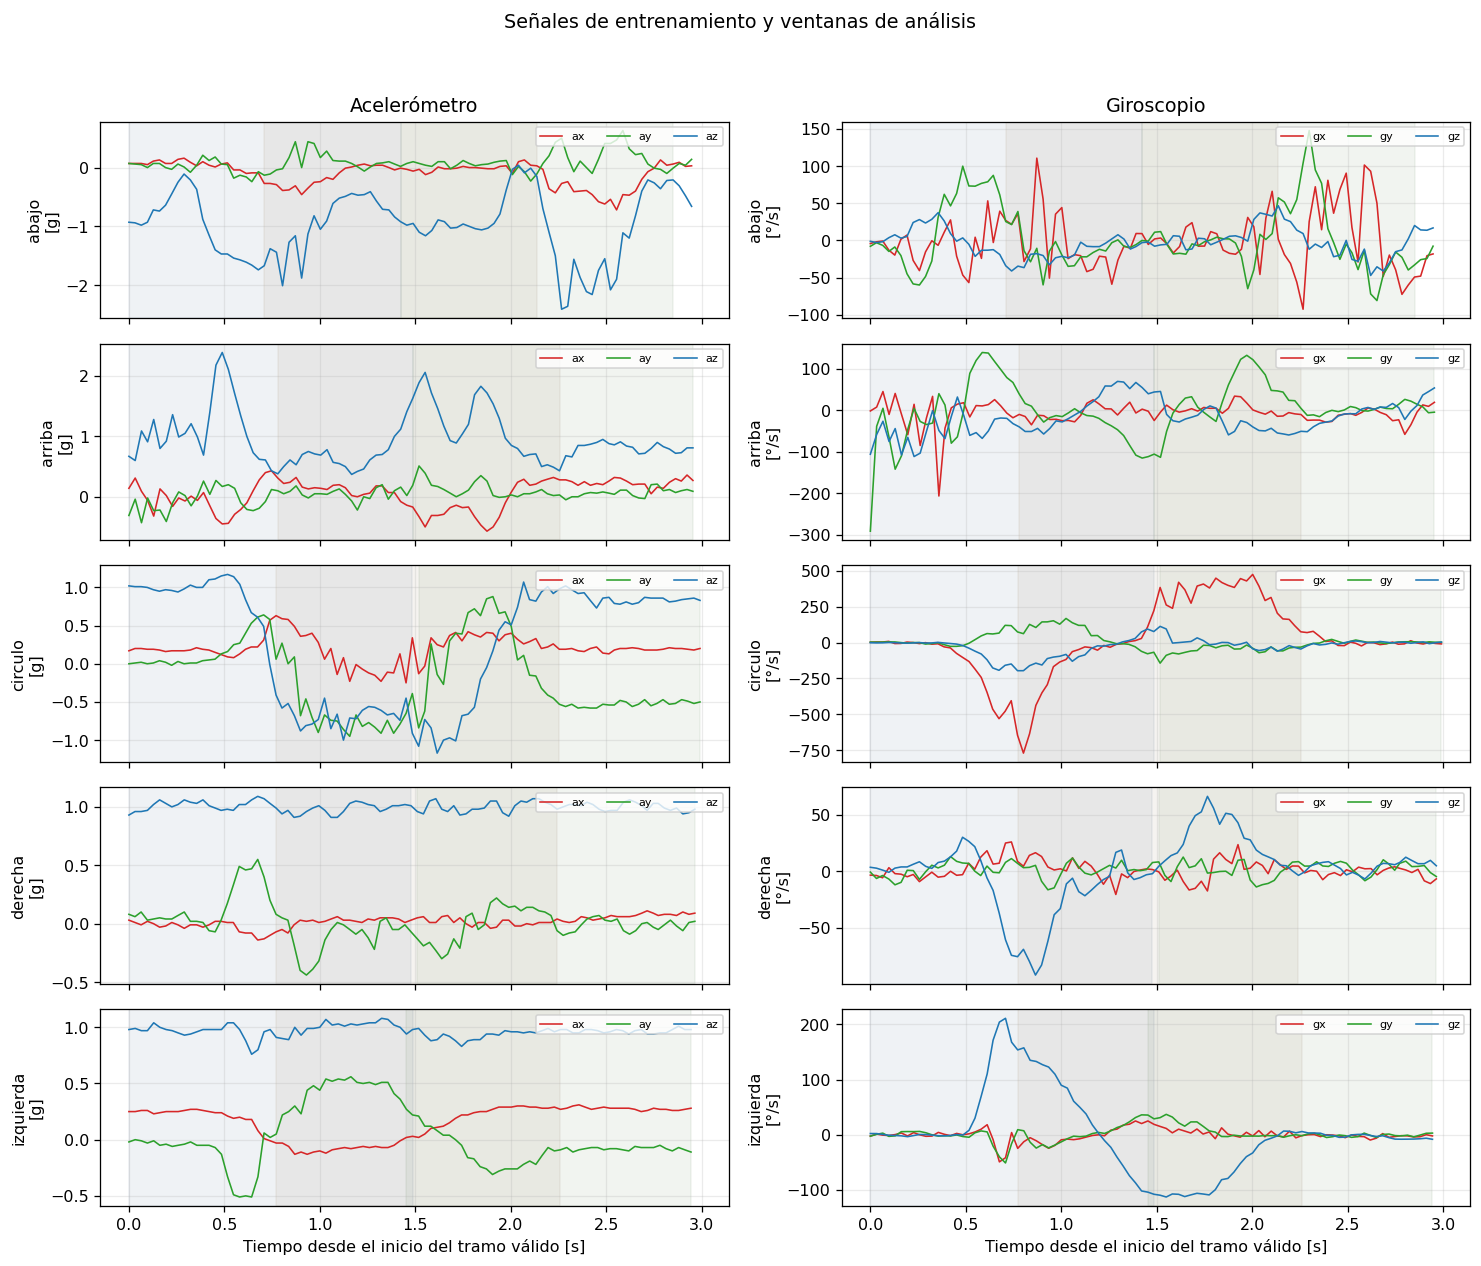

In [5]:
def indices_ventanas(n, fs):
    largo = max(32, int(round(VENTANA_S * fs)))
    paso = max(1, int(round(largo * (1 - SOLAPE))))
    if n < largo:
        return [(0, n)]
    segmentos = [(i, i + largo) for i in range(0, n - largo + 1, paso)]
    if segmentos[-1][1] < n and n - segmentos[-1][1] >= paso // 2:
        segmentos.append((n - largo, n))
    return segmentos

gestos = sorted(np.unique(y_tr))
fig, axes = plt.subplots(5, 2, figsize=(13, 11), sharex=True)
for fila, gesto in enumerate(gestos):
    ejemplo = df.iloc[idx_tr].query("gesture == @gesto").sort_values("source_file").iloc[0]
    ruta = Path("data/raw") / ejemplo["source_file"]
    senal, fs, diagnostico = cargar_y_limpiar(str(ruta), cfg)
    assert senal is not None
    t = (senal.timestamp_ms - senal.timestamp_ms.iloc[0]) / 1000
    for ax, columnas, unidad in zip(axes[fila], [("ax", "ay", "az"), ("gx", "gy", "gz")], ["g", "°/s"]):
        for canal, color in zip(columnas, ["#d62728", "#2ca02c", "#1f77b4"]):
            ax.plot(t, senal[canal], color=color, label=canal, lw=1)
        for k, (ini, fin) in enumerate(indices_ventanas(len(senal), fs)):
            ax.axvspan(t.iloc[ini], t.iloc[fin - 1], alpha=0.08,
                       color=["#335c81", "#8b6b45", "#50754a"][k % 3])
        ax.set_ylabel(f"{gesto}\n[{unidad}]")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=7, ncol=3, loc="upper right")
axes[0, 0].set_title("Acelerómetro")
axes[0, 1].set_title("Giroscopio")
for ax in axes[-1]:
    ax.set_xlabel("Tiempo desde el inicio del tramo válido [s]")
fig.suptitle("Señales de entrenamiento y ventanas de análisis", y=0.998)
fig.tight_layout(rect=(0, 0, 1, 0.975))
fig.savefig("results/figures/senales_por_clase.png", dpi=135)
plt.show()


## F. Elegir y visualizar el espacio 2D/3D
Se comparan seis representaciones: pares y tríos de características originales,
PCA de 2 y 3 componentes, y LDA de 2 y 3 componentes. Cada una se combina con el
clasificador propio de fronteras lineales o cuadráticas.

La búsqueda de pares/tríos usa $J=\operatorname{tr}(S_W^{-1}S_B)$:
dispersión entre clases frente a dispersión dentro de cada clase. PCA conserva
variación; LDA usa las etiquetas para favorecer la separación. LD1/LD2/LD3 son
combinaciones de características y no los ejes físicos de la placa.

**Selección:** validación cruzada agrupada de cinco pliegues **solo dentro del
70 % de entrenamiento**. En cada pliegue se vuelven a seleccionar columnas y a
ajustar el escalador, el reductor y el clasificador. La mayor exactitud balanceada
media decide; en empates se prefiere menos dimensiones, fronteras lineales y
menor desviación. Las cifras de esta validación sirven para seleccionar; la
evaluación de prueba se realiza más adelante, con la elección ya fijada.


In [6]:
def ajustar_representacion(tabla, etiquetas, tipo, dim, columnas=None):
    if tipo == "Caracteristicas":
        columnas = columnas or list(mejores_combinaciones(tabla, etiquetas, n_dim=dim, top=1)[0][1])
    else:
        columnas = list(tabla.columns)
    escalador = StandardScaler().fit(tabla[columnas])
    A = escalador.transform(tabla[columnas])
    reductor = None
    if tipo == "PCA":
        reductor = PCA(n_components=dim, random_state=RANDOM_STATE).fit(A)
    elif tipo == "LDA":
        reductor = LDA(n_components=dim).fit(A, etiquetas)
    return {"tipo": tipo, "dim": dim, "columnas": columnas,
            "escalador": escalador, "reductor": reductor}

def transformar(representacion, tabla):
    A = representacion["escalador"].transform(tabla[representacion["columnas"]])
    reductor = representacion["reductor"]
    return A if reductor is None else reductor.transform(A)

def etiquetas_ejes(representacion):
    if representacion["tipo"] == "Caracteristicas":
        return [c + " (estandarizada)" for c in representacion["columnas"]]
    prefijo = "LD" if representacion["tipo"] == "LDA" else "PC"
    return [f"{prefijo}{i + 1}" for i in range(representacion["dim"])]


In [7]:
cv = StratifiedGroupKFold(n_splits=N_PLIEGUES, shuffle=True, random_state=RANDOM_STATE)
filas_cv = []
for pliegue, (ent, val) in enumerate(cv.split(X_tr, y_tr, groups=grupos_tr), start=1):
    assert not (set(grupos_tr[ent]) & set(grupos_tr[val]))
    A, B = X_tr.iloc[ent], X_tr.iloc[val]
    ya, yb = y_tr[ent], y_tr[val]
    assert set(ya) == set(yb) == set(y_tr)
    print(f"Validación interna: pliegue {pliegue}/{N_PLIEGUES}")
    for dim in (2, 3):
        for tipo in ("Caracteristicas", "PCA", "LDA"):
            rep = ajustar_representacion(A, ya, tipo, dim)
            Za, Zb = transformar(rep, A), transformar(rep, B)
            for cov in ("comun", "propia"):
                candidato = ClasificadorGaussianoCuadratico(reg=REGULARIZACION, covarianza=cov).fit(Za, ya)
                filas_cv.append({"proyeccion": tipo, "dim": dim, "covarianza": cov,
                                 "frontera": "lineal" if cov == "comun" else "cuadratica",
                                 "pliegue": pliegue,
                                 "balanced_accuracy": balanced_accuracy_score(yb, candidato.predict(Zb))})
detalle_cv = pd.DataFrame(filas_cv)
comparacion = detalle_cv.groupby(["proyeccion", "dim", "covarianza", "frontera"], as_index=False).agg(
    media=("balanced_accuracy", "mean"), desv=("balanced_accuracy", lambda x: x.std(ddof=0)))
comparacion["preferencia_lineal"] = (comparacion.covarianza != "comun").astype(int)
comparacion = comparacion.sort_values(["media", "dim", "preferencia_lineal", "desv"],
                                     ascending=[False, True, True, True]).drop(columns="preferencia_lineal").reset_index(drop=True)
elegido = comparacion.iloc[0].to_dict()
detalle_cv.to_csv("results/metrics/validacion_interna_detalle.csv", index=False)
comparacion.to_csv("results/metrics/seleccion_modelo.csv", index=False)
print("\nComparación de candidatos (proporciones de 0 a 1):")
print(comparacion.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nElección: {elegido['proyeccion']}, {int(elegido['dim'])}D, frontera {elegido['frontera']}")


Validación interna: pliegue 1/5
Validación interna: pliegue 2/5
Validación interna: pliegue 3/5
Validación interna: pliegue 4/5
Validación interna: pliegue 5/5

Comparación de candidatos (proporciones de 0 a 1):
     proyeccion  dim covarianza   frontera  media   desv
            LDA    3      comun     lineal 0.8422 0.0149
            LDA    3     propia cuadratica 0.8080 0.0296
            LDA    2      comun     lineal 0.7596 0.0257
Caracteristicas    3      comun     lineal 0.6911 0.0428
Caracteristicas    2      comun     lineal 0.6853 0.0396
Caracteristicas    2     propia cuadratica 0.6844 0.0282
Caracteristicas    3     propia cuadratica 0.6809 0.0433
            LDA    2     propia cuadratica 0.6796 0.0473
            PCA    3      comun     lineal 0.6587 0.0451
            PCA    3     propia cuadratica 0.6542 0.0498
            PCA    2     propia cuadratica 0.4382 0.0409
            PCA    2      comun     lineal 0.3840 0.0616

Elección: LDA, 3D, frontera lineal


Mejor combinación 2D en entrenamiento: ['ay_variance', 'az_mean']
Mejor combinación 3D en entrenamiento: ['ay_variance', 'az_mean', 'gx_variance']


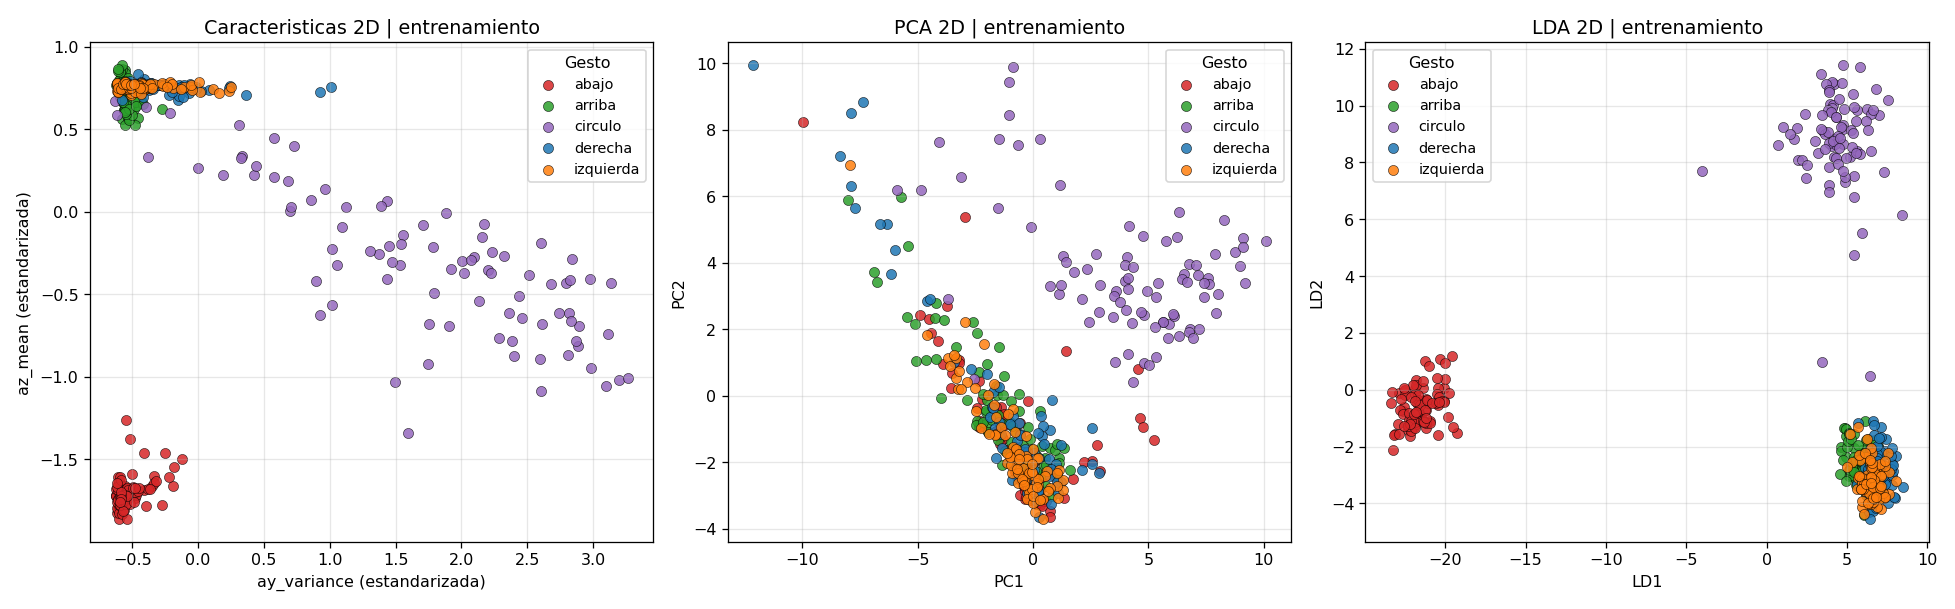

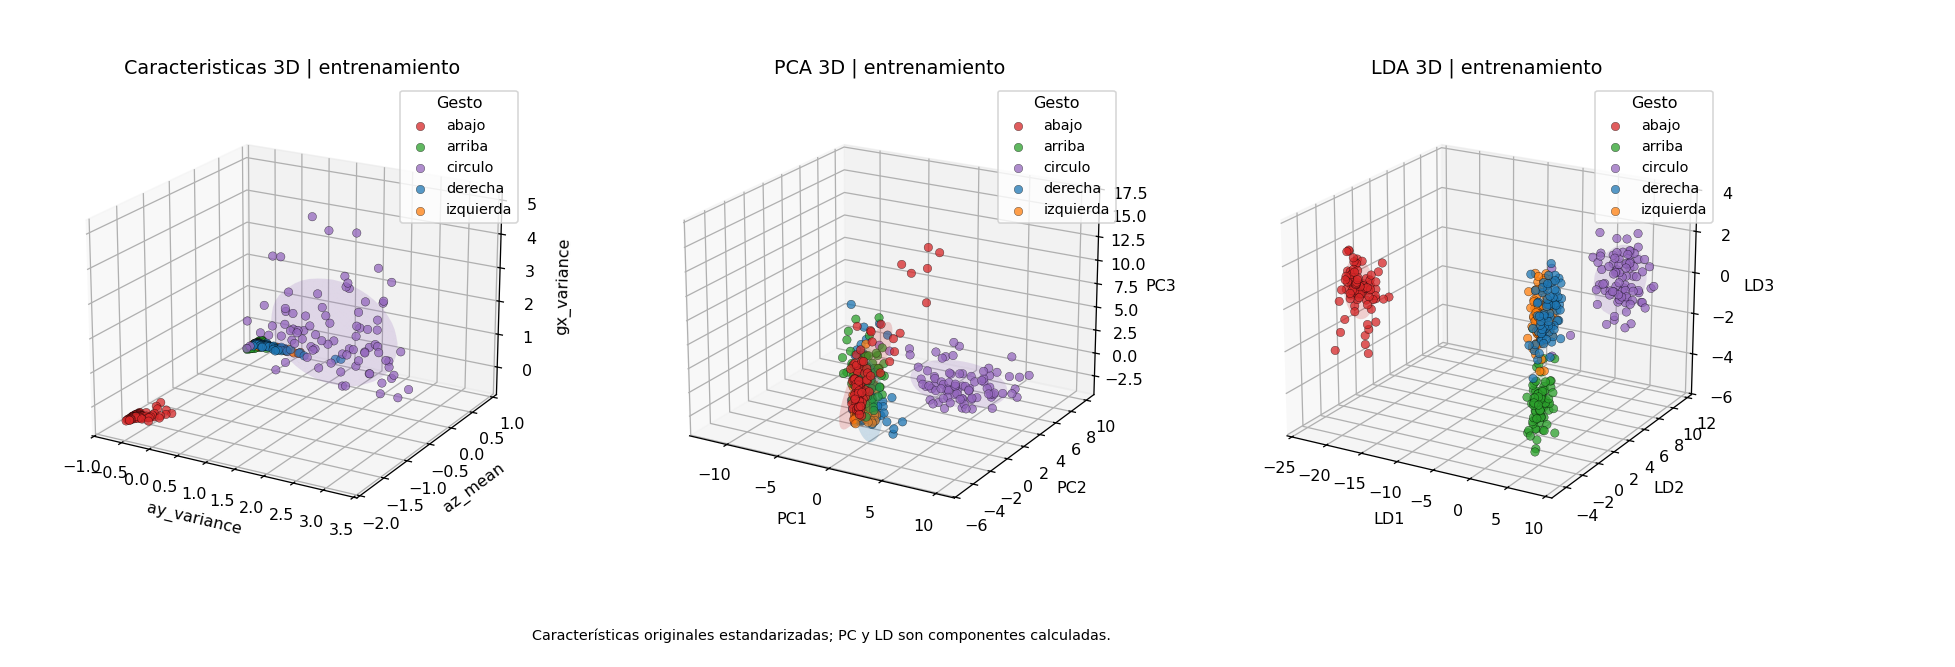

Las superficies translúcidas describen la dispersión de cada clase; no son fronteras de decisión.


In [8]:
# Representaciones ajustadas en todo entrenamiento para las figuras finales.
representaciones = {}
filas_fisher = []
for dim in (2, 3):
    for tipo in ("Caracteristicas", "PCA", "LDA"):
        rep = ajustar_representacion(X_tr, y_tr, tipo, dim)
        representaciones[(tipo, dim)] = rep
        Z = transformar(rep, X_tr)
        filas_fisher.append({"proyeccion": tipo, "dim": dim, "J_entrenamiento": criterio_fisher(Z, y_tr)})
        if tipo == "Caracteristicas":
            print(f"Mejor combinación {dim}D en entrenamiento:", rep["columnas"])
pd.DataFrame(filas_fisher).to_csv("results/metrics/separacion_entrenamiento.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.3))
for ax, tipo in zip(axes, ("Caracteristicas", "PCA", "LDA")):
    rep = representaciones[(tipo, 2)]
    Z = transformar(rep, X_tr)
    graficar_dispersion_2d(Z, y_tr, etiquetas=etiquetas_ejes(rep),
                           titulo=f"{tipo} 2D | entrenamiento", ax=ax)
fig.tight_layout()
fig.savefig("results/figures/dispersion_2d.png", dpi=130)
plt.show()

fig = plt.figure(figsize=(17, 5.8))
for i, tipo in enumerate(("Caracteristicas", "PCA", "LDA"), start=1):
    rep = representaciones[(tipo, 3)]
    graficar_dispersion_3d(transformar(rep, X_tr), y_tr,
                          etiquetas=[e.replace(" (estandarizada)", "") for e in etiquetas_ejes(rep)], titulo=f"{tipo} 3D | entrenamiento",
                          ax=fig.add_subplot(1, 3, i, projection="3d"))
fig.subplots_adjust(left=0.03, right=0.88, bottom=0.15, top=0.90, wspace=0.28)
fig.text(0.42, 0.04, "Características originales estandarizadas; PC y LD son componentes calculadas.", ha="center", fontsize=9)
fig.savefig("results/figures/dispersion_3d.png", dpi=135)
plt.show()
print("Las superficies translúcidas describen la dispersión de cada clase; no son fronteras de decisión.")


## G. Clasificador propio y funciones que delimitan el espacio
Se conserva la implementación propia en `scripts/clasificador_geometrico.py`.
Para cada clase se calcula su centro, su covarianza y una función discriminante.
El punto se asigna a la clase con el mayor valor de esa función. La variante
lineal comparte covarianza; la cuadrática estima una por clase y la regulariza.
La variante y la dimensión se acaban de elegir mediante validación interna.


Cada clase $c$ se modela con una normal multivariante en el espacio reducido:

$$p(z \mid c) = \frac{1}{(2\pi)^{D/2}\,|S_c|^{1/2}}
\exp\!\left(-\tfrac{1}{2}(z-\mu_c)^{T} S_c^{-1} (z-\mu_c)\right)$$

Por la regla de Bayes, y tomando logaritmo, la **función discriminante** de la clase
$c$ (descartando términos constantes comunes a todas) es:

$$g_c(z) = -\frac{1}{2}(z-\mu_c)^{T} S_c^{-1} (z-\mu_c)
           -\frac{1}{2}\ln|S_c| + \ln P(c)$$

$$\mu_c = \frac{1}{N_c}\sum_{i \in c} z_i
\qquad
S_c = \frac{1}{N_c-1}\sum_{i \in c}(z_i-\mu_c)(z_i-\mu_c)^{T}
\qquad
P(c) = \frac{N_c}{N}$$

La decisión es $\;\text{clase}(z) = \arg\max_c\, g_c(z)$.

### Fronteras entre clases

La frontera entre dos clases $i$ y $j$ es el lugar donde ambas funciones se igualan,
$g_i(z) - g_j(z) = 0$. Desarrollando los productos matriciales, esa diferencia es un
polinomio de **segundo grado**:

$$f_{ij}(z) = z^{T} A_{ij}\, z + b_{ij}^{T} z + c_{ij} = 0$$

$$A_{ij} = -\tfrac{1}{2}\big(S_i^{-1} - S_j^{-1}\big)
\qquad
b_{ij} = S_i^{-1}\mu_i - S_j^{-1}\mu_j$$

$$c_{ij} = -\tfrac{1}{2}\big(\mu_i^{T} S_i^{-1}\mu_i - \mu_j^{T} S_j^{-1}\mu_j\big)
           -\tfrac{1}{2}\big(\ln|S_i| - \ln|S_j|\big)
           + \ln P(i) - \ln P(j)$$

En 2D cada frontera es una **cónica** (elipse, parábola o hipérbola); en 3D, una
**cuádrica** (elipsoide, paraboloide o hiperboloide). Son exactamente las funciones que
delimitan cada región del espacio, y el método `coeficientes_frontera()` las devuelve
para poder escribirlas en el informe.

**Caso particular:** si se impone una única matriz de covarianza común a todas las
clases, entonces $S_i = S_j$, luego $A_{ij} = 0$ y la frontera degenera en un
**hiperplano** $b_{ij}^{T} z + c_{ij} = 0$ (rectas en 2D, planos en 3D).

### Regularización de la variante cuadrática

Con pocas ventanas por clase, $S_c$ puede quedar mal condicionada. Se encoge hacia la
covarianza global:

$$S_c^{\text{reg}} = (1-\lambda)\,S_c + \lambda\,S_{\text{global}},
\qquad 0 \le \lambda \le 1$$


In [9]:
TIPO = elegido["proyeccion"]
DIM = int(elegido["dim"])
COVARIANZA = elegido["covarianza"]
representacion_final = representaciones[(TIPO, DIM)]
Z_tr = transformar(representacion_final, X_tr)
modelo = ClasificadorGaussianoCuadratico(reg=REGULARIZACION, covarianza=COVARIANZA).fit(Z_tr, y_tr)
print(f"Modelo fijado antes de evaluar prueba: {TIPO} {DIM}D, frontera {elegido['frontera']}")
print(f"Exactitud de entrenamiento: {modelo.score(Z_tr, y_tr):.2%}")
modelo.imprimir_fronteras(decimales=4)

# Comprobar las ecuaciones frente a las funciones discriminantes.
import itertools
G = modelo.funciones_discriminantes(Z_tr)
errores = []
fronteras = []
for i, j in itertools.combinations(range(len(modelo.clases_)), 2):
    ci, cj = modelo.clases_[i], modelo.clases_[j]
    f = modelo.coeficientes_frontera(ci, cj)
    valor = np.einsum("ij,jk,ik->i", Z_tr, f["A"], Z_tr) + Z_tr @ f["b"] + f["c"]
    errores.append(float(np.abs(valor - (G[:, i] - G[:, j])).max()))
    fronteras.append({"clase_i": ci, "clase_j": cj, "tipo": f["tipo"],
                      "A": f["A"].tolist(), "b": f["b"].tolist(), "c": f["c"]})
assert max(errores) < 1e-7
Path("results/metrics/fronteras.json").write_text(json.dumps(fronteras, ensure_ascii=False, indent=2), encoding="utf-8")
print("\nMáximo error al verificar las 10 ecuaciones:", max(errores))


Modelo fijado antes de evaluar prueba: LDA 3D, frontera lineal
Exactitud de entrenamiento: 86.90%

Frontera abajo / arriba  (lineal):
  -0.0000 z1^2 -0.0000 z2^2 -0.0000 z3^2
  -0.0000 z1 z2 -0.0000 z1 z3 -0.0000 z2 z3
  -27.2978 z1 +1.9644 z2 +3.0095 z3 -208.1859 = 0

Frontera abajo / circulo  (lineal):
  -0.0000 z1^2 -0.0000 z2^2 -0.0000 z3^2
  -0.0000 z1 z2 -0.0000 z1 z3 -0.0000 z2 z3
  -25.9561 z1 -9.3709 z2 -0.0094 z3 -184.3693 = 0

Frontera abajo / derecha  (lineal):
  -0.0000 z1^2 -0.0000 z2^2 -0.0000 z3^2
  -0.0000 z1 z2 -0.0000 z1 z3 -0.0000 z2 z3
  -28.5150 z1 +2.2866 z2 -1.2374 z3 -202.9905 = 0

Frontera abajo / izquierda  (lineal):
  -0.0000 z1^2 -0.0000 z2^2 -0.0000 z3^2
  -0.0000 z1 z2 -0.0000 z1 z3 -0.0000 z2 z3
  -28.0514 z1 +2.5964 z2 -1.1904 z3 -205.3345 = 0

Frontera arriba / circulo  (lineal):
  -0.0000 z1^2 -0.0000 z2^2 -0.0000 z3^2
  -0.0000 z1 z2 -0.0000 z1 z3 -0.0000 z2 z3
  +1.3418 z1 -11.3353 z2 -3.0190 z3 +23.8167 = 0

Frontera arriba / derecha  (lineal):
  -

Las fronteras se visualizan aplicando **el mismo modelo seleccionado** a una
malla de puntos. En 2D se muestra el plano completo. En 3D se muestran tres
cortes con la tercera coordenada fija; cada panel es un corte del clasificador
3D y no un modelo diferente entrenado en dos dimensiones.


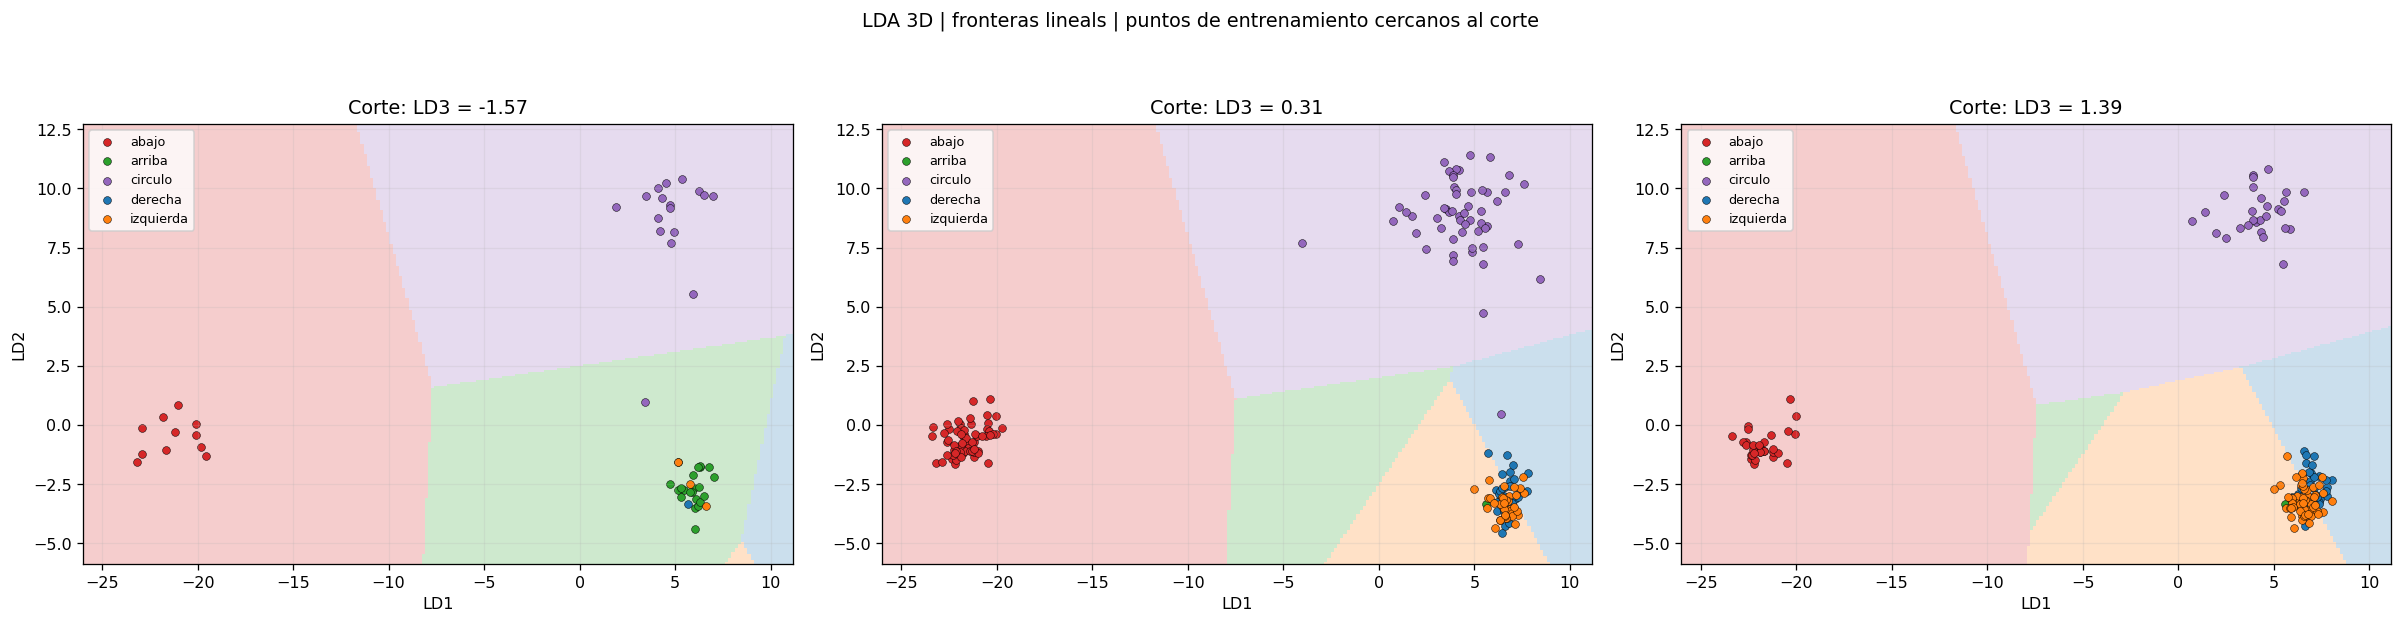

In [10]:
from matplotlib.colors import ListedColormap, BoundaryNorm
colores = [_COLORES[c] for c in modelo.clases_]
mapa = ListedColormap(colores)
norma = BoundaryNorm(np.arange(len(colores) + 1) - 0.5, len(colores))
rangos = np.ptp(Z_tr, axis=0)
limites_min = Z_tr.min(axis=0) - 0.08 * rangos
limites_max = Z_tr.max(axis=0) + 0.08 * rangos
xx, yy = np.meshgrid(np.linspace(limites_min[0], limites_max[0], 220),
                     np.linspace(limites_min[1], limites_max[1], 220))
cortes = [None] if DIM == 2 else list(np.quantile(Z_tr[:, 2], [0.2, 0.5, 0.8]))
fig, axes = plt.subplots(1, len(cortes), figsize=(7 * len(cortes), 5.5), squeeze=False)
ejes = etiquetas_ejes(representacion_final)
for ax, corte in zip(axes.ravel(), cortes):
    malla = np.c_[xx.ravel(), yy.ravel()]
    if DIM == 3:
        malla = np.c_[malla, np.full(len(malla), corte)]
    pred = modelo.predict(malla)
    indices = np.searchsorted(modelo.clases_, pred).reshape(xx.shape)
    ax.pcolormesh(xx, yy, indices, cmap=mapa, norm=norma, alpha=0.23, shading="auto")
    cerca = np.ones(len(Z_tr), dtype=bool) if DIM == 2 else np.abs(Z_tr[:, 2] - corte) <= 0.10 * rangos[2]
    for clase, color in zip(modelo.clases_, colores):
        mask = (y_tr == clase) & cerca
        ax.scatter(Z_tr[mask, 0], Z_tr[mask, 1], color=color, label=clase, s=24, edgecolors="black", linewidths=0.3)
    ax.set_xlabel(ejes[0]); ax.set_ylabel(ejes[1])
    ax.set_title("Regiones de decisión 2D" if DIM == 2 else f"Corte: {ejes[2]} = {corte:.2f}")
    ax.grid(alpha=0.2); ax.legend(fontsize=8)
fig.suptitle(f"{TIPO} {DIM}D | fronteras {elegido['frontera']}s | puntos de entrenamiento cercanos al corte")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig("results/figures/regiones_decision.png", dpi=130)
plt.show()


## H. Evaluación final en prueba
La elección ya está fijada. Ahora se transforma prueba con la representación
ajustada en entrenamiento y se predice sin volver a entrenar. Se reportan aciertos
globales y exactitud balanceada (promedio de la sensibilidad de las cinco clases).
Cada punto evaluado representa una ventana; las ventanas de una grabación no son
observaciones independientes. La matriz de confusión identifica los errores.


Aciertos: 154 de 180 ventanas de prueba
Exactitud: 85.56%
Exactitud balanceada: 86.32%
              precision    recall  f1-score   support

       abajo      1.000     1.000     1.000        30
      arriba      0.974     0.905     0.938        42
     circulo      1.000     0.970     0.985        33
     derecha      0.769     0.714     0.741        42
   izquierda      0.600     0.727     0.658        33

    accuracy                          0.856       180
   macro avg      0.869     0.863     0.864       180
weighted avg      0.867     0.856     0.859       180



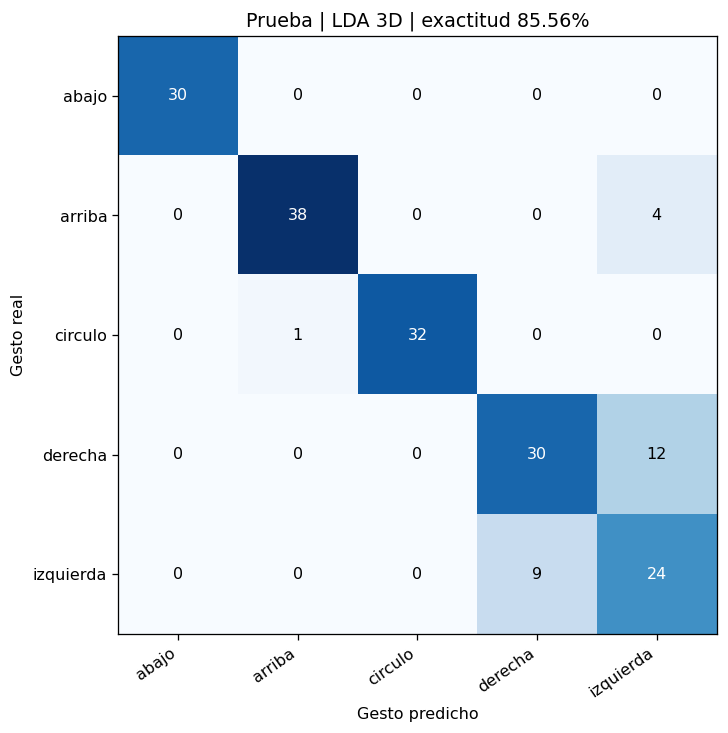

Confusiones más frecuentes (real → predicho):
gesture    prediccion
derecha    izquierda     12
izquierda  derecha        9
arriba     izquierda      4
circulo    arriba         1


In [11]:
Z_te = transformar(representacion_final, X_te)
y_pred = modelo.predict(Z_te)
clases = list(modelo.clases_)
aciertos = int(np.sum(y_te == y_pred))
accuracy = accuracy_score(y_te, y_pred)
balanced = balanced_accuracy_score(y_te, y_pred)
print(f"Aciertos: {aciertos} de {len(y_te)} ventanas de prueba")
print(f"Exactitud: {accuracy:.2%}")
print(f"Exactitud balanceada: {balanced:.2%}")
print(classification_report(y_te, y_pred, labels=clases, digits=3, zero_division=0))
pd.DataFrame(classification_report(y_te, y_pred, labels=clases, output_dict=True, zero_division=0)).T.to_csv("results/metrics/classification_report.csv")
predicciones = df.iloc[idx_te][["segment_id", "recording_id", "gesture"]].copy()
predicciones["prediccion"] = y_pred
predicciones.to_csv("results/metrics/predicciones_prueba.csv", index=False)
cm = confusion_matrix(y_te, y_pred, labels=clases)
pd.DataFrame(cm, index=clases, columns=clases).to_csv("results/metrics/matriz_confusion.csv")
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.imshow(cm, cmap="Blues", vmin=0)
for i in range(5):
    for j in range(5):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > cm.max()*0.6 else "black")
ax.set_xticks(range(5), clases, rotation=35, ha="right")
ax.set_yticks(range(5), clases)
ax.set_xlabel("Gesto predicho"); ax.set_ylabel("Gesto real")
ax.set_title(f"Prueba | {TIPO} {DIM}D | exactitud {accuracy:.2%}")
fig.tight_layout(); fig.savefig("results/figures/confusion_matrix.png", dpi=140)
plt.show()

fallos = predicciones.query("gesture != prediccion").groupby(["gesture", "prediccion"]).size().sort_values(ascending=False)
print("Confusiones más frecuentes (real → predicho):")
print(fallos.head(5).to_string() if len(fallos) else "No hubo errores en esta partición.")


## I. Guardar el modelo y documentar los resultados
Se guarda exactamente el modelo evaluado (ajustado al 70 % de entrenamiento),
junto con la representación y el orden de las columnas. Las predicciones de carga
comprueban que guardar y recuperar no modifica sus resultados.


In [12]:
paquete = {"representacion": representacion_final, "clasificador": modelo,
           "columnas_entrada": list(X.columns), "clases": clases,
           "ventana_s": VENTANA_S, "solape": SOLAPE,
           "ajuste": "solo entrenamiento; 140 grabaciones en el dataset recibido"}
joblib.dump(paquete, "results/models/gesture_classifier.joblib")

def predecir(paquete, tabla_caracteristicas):
    Z = transformar(paquete["representacion"], tabla_caracteristicas)
    return paquete["clasificador"].predict(Z)

# El archivo se acaba de generar en esta ejecución.
recuperado = joblib.load("results/models/gesture_classifier.joblib")
assert np.array_equal(predecir(recuperado, X_te), y_pred)
versiones = {"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__,
             "scipy": scipy.__version__, "scikit-learn": sklearn.__version__,
             "matplotlib": matplotlib.__version__, "joblib": joblib.__version__}
resumen = {"integrantes": ["William David Olaya", "Nelson Leonardo Hernandez"],
           "placa_reportada": "Arduino Nano BLE Sense", "colocacion": "en la mano",
           "grabaciones": int(df.recording_id.nunique()), "ventanas": len(df), "n_caracteristicas": X.shape[1],
           "fs_hz_mediana": float(df.fs_hz.median()),
           "n_entrenamiento": len(X_tr), "n_prueba": len(X_te), "aciertos_prueba": aciertos,
           "proyeccion": TIPO, "dim": DIM, "covarianza": COVARIANZA,
           "cv_interna_balanced_accuracy": float(elegido["media"]),
           "accuracy_prueba": float(accuracy), "balanced_accuracy_prueba": float(balanced),
           "versiones": versiones}
Path("results/metrics/resumen_ejecucion.json").write_text(json.dumps(resumen, ensure_ascii=False, indent=2), encoding="utf-8")
texto = (f"# Resultados de la ejecución\n\n"
         f"Integrantes: William David Olaya y Nelson Leonardo Hernandez.\n\n"
         f"Se analizaron {len(df)} ventanas de {df.recording_id.nunique()} grabaciones. "
         f"La selección interna eligió {TIPO} {DIM}D con frontera {elegido['frontera']}. "
         f"La exactitud balanceada media de selección fue {elegido['media']:.2%}.\n\n"
         f"En las {len(y_te)} ventanas de prueba acertó {aciertos}: exactitud {accuracy:.2%} "
         f"y exactitud balanceada {balanced:.2%}. Estas medidas tienen denominadores distintos.\n\n"
         f"La evaluación corresponde al participante y sesión identificados en los archivos. "
         f"El dataset ya fue explorado en una versión anterior; una sesión nueva permitiría una "
         f"confirmación prospectiva. Las ventanas están agrupadas por grabación para evitar "
         f"que fragmentos del mismo movimiento se repartan entre ajuste y evaluación.\n")
Path("RESULTADOS_ACTUALES.md").write_text(texto, encoding="utf-8")
print(texto)
print("Versiones utilizadas:", versiones)


# Resultados de la ejecución

Integrantes: William David Olaya y Nelson Leonardo Hernandez.

Se analizaron 600 ventanas de 200 grabaciones. La selección interna eligió LDA 3D con frontera lineal. La exactitud balanceada media de selección fue 84.22%.

En las 180 ventanas de prueba acertó 154: exactitud 85.56% y exactitud balanceada 86.32%. Estas medidas tienen denominadores distintos.

La evaluación corresponde al participante y sesión identificados en los archivos. El dataset ya fue explorado en una versión anterior; una sesión nueva permitiría una confirmación prospectiva. Las ventanas están agrupadas por grabación para evitar que fragmentos del mismo movimiento se repartan entre ajuste y evaluación.

Versiones utilizadas: {'python': '3.12.13', 'numpy': '2.3.5', 'pandas': '2.2.3', 'scipy': '1.17.0', 'scikit-learn': '1.8.0', 'matplotlib': '3.10.8', 'joblib': '1.5.3'}


## J. Interpretación, limitaciones y entrega
- Las gráficas permiten comparar la separación; el mejor par se busca por separado del mejor trío.
- El criterio de selección fue la validación interna, no observar qué candidato acertaba más en prueba.
- La tabla de confusiones muestra qué gestos siguen superponiéndose. Una separación visual no garantiza aciertos con una persona nueva.
- Los archivos representan una persona identificada y una sesión. No permiten concluir rendimiento entre personas o sesiones.
- La placa se colocó en la mano; la orientación inicial no quedó documentada. Parte de la diferencia puede depender de la postura y de la gravedad medida por el acelerómetro.
- Se conserva la ventana de 1,5 s elegida en el trabajo previo. Este dataset ya fue explorado; los resultados actuales son retrospectivos. Una captura nueva serviría como confirmación adicional.
- El archivo extendido y los resultados de la versión recibida son material histórico. Los resultados del presente cuaderno están en `results/` y `RESULTADOS_ACTUALES.md`.

**Para Moodle:** subir todos los archivos a GitHub, ejecutar desde una sesión nueva de Colab,
comprobar la descarga y descargar el `.ipynb` con sus salidas visibles.

Fuentes metodológicas: [scikit-learn: evitar fuga de información](https://scikit-learn.org/stable/common_pitfalls.html)
y [validación cruzada](https://scikit-learn.org/stable/modules/cross_validation.html).
